In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower

## Task 1 — Data Exploration and Assumption Checks

Shape: (244, 7)
Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
Null values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


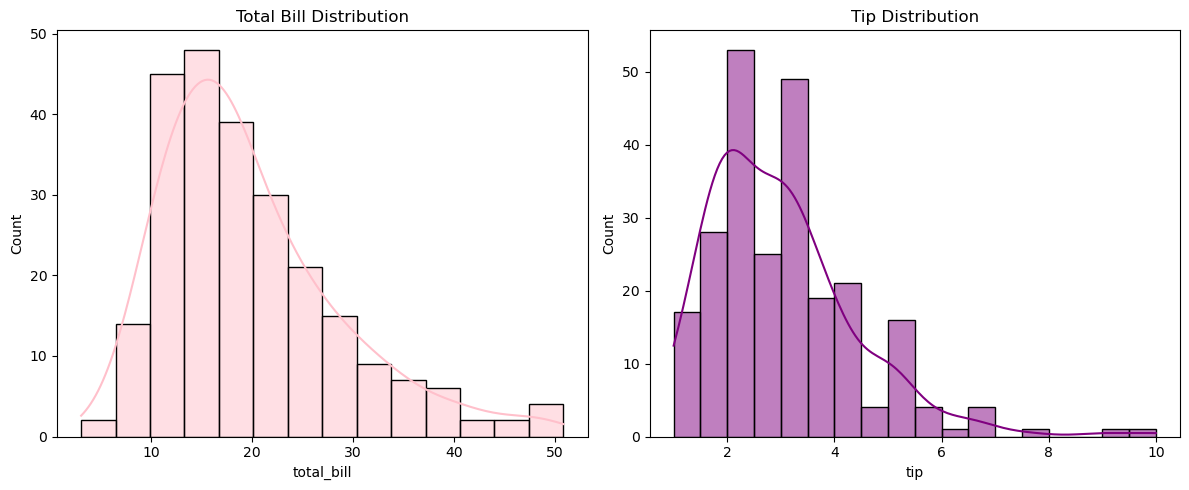

In [2]:
df=sns.load_dataset("tips")
print(f"Shape: {df.shape}")
print("Types:")
print(df.dtypes)
print("Null values:")
print(df.isnull().sum())
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['total_bill'], kde=True, color='pink')
plt.title("Total Bill Distribution")
plt.subplot(1,2,2)
sns.histplot(df["tip"], kde=True, color="purple")
plt.title("Tip Distribution")
plt.tight_layout()
plt.show()

---TOTAL_BILL Analysis:


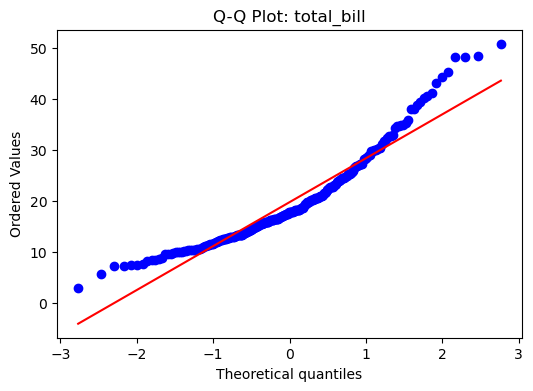

Shapiro-Wilk Test: (total_bill): p-value=0.0000
Result: total_bill isn't a normal distribution (Assumption violated).
--- Levene's Test for: TOTAL_BILL (Smoker) ---
Statistics: 4.0537, P-value: 0.0452
Result: Variances aren't equal (Heteroscedasticity - Assumption violated).
---TIP Analysis:


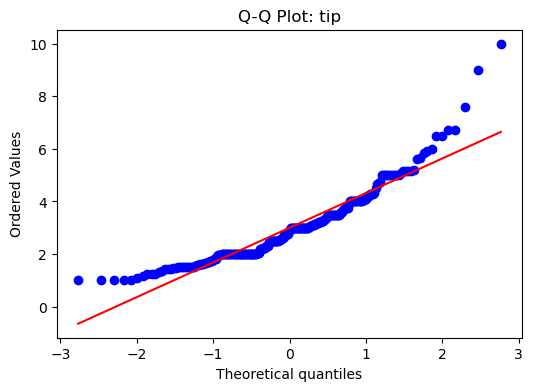

Shapiro-Wilk Test: (tip): p-value=0.0000
Result: tip isn't a normal distribution (Assumption violated).
--- Levene's Test for: TIP (Smoker) ---
Statistics: 0.0205, P-value: 0.8862
Result: Variances are equal (Homoscedasticity).


In [3]:
variables=["total_bill", "tip"]
for variable in variables:
    print(f"---{variable.upper()} Analysis:")
    #Q-Q plot
    plt.figure(figsize=(6,4))
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {variable}")
    plt.show()
    #Shapiro-Wilk 
    stat, p=stats.shapiro(df[variable])
    print(f"Shapiro-Wilk Test: ({variable}): p-value={p:.4f}")
    if p > 0.05:
        print(f"Result: {variable} is a normal distribution") 
    else:
        print(f"Result: {variable} isn't a normal distribution (Assumption violated).")
    print(f"--- Levene's Test for: {variable.upper()} (Smoker) ---")
    smoker_yes=df[df["smoker"]=="Yes"][variable]
    smoker_no=df[df["smoker"]=="No"][variable]
    stat, p=stats.levene(smoker_yes, smoker_no)
    print(f"Statistics: {stat:.4f}, P-value: {p:.4f}")
    if p > 0.05:
        print(f"Result: Variances are equal (Homoscedasticity).")
    else:
        print(f"Result: Variances aren't equal (Heteroscedasticity - Assumption violated).")

**Normality Assumption (Shapiro-Wilk Test):**

- Violation: Both total_bill and tip variables violated the normality assumption. The Shapiro-Wilk test returned a p-value of 0.0000 for both, which is much lower than the significance level of $\alpha = 0.05$.

- Visual Confirmation: The Q-Q plots also showed significant deviations from the diagonal line, confirming that the data is right-skewed.

**Equal Variance Assumption (Levene’s Test):**

- Total Bill: The Levene’s test for total_bill across smoker groups resulted in a p-value of 0.0452. Since $p < 0.05$, the assumption of equal variance (homoscedasticity) is violated.

- Tip: The Levene’s test for tip resulted in a p-value of 0.8862. Since $p > 0.05$, the assumption of equal variance is satisfied for this variable.

**Influence on Test Selection:**

- Non-Parametric Priority: Because the normality assumption is violated for both main variables, I will use the Mann-Whitney U test (a non-parametric alternative to the Independent T-test) to compare groups. This test does not require the data to follow a normal distribution.

- Welch’s Consideration: For any parametric comparisons involving total_bill, I would need to use Welch’s T-test instead of a standard T-test to account for unequal variances.

- Categorical Analysis: For relationships between two categorical variables (like sex and smoker), I will use the Chi-Square Test of Independence, as it is appropriate for nominal data.

## Task 2 — Hypothesis Test Selection and Execution

**Research Question 1: Is there a significant difference in Total Bill between smokers and non-smokers?**

a. Hypotheses:
- Null Hypothesis ($H_0$): There is no significant difference in the median total bill between smokers and non-smokers ($\text{Median}_{\text{smoker}} = \text{Median}_{\text{non-smoker}}$).
- Alternative Hypothesis ($H_a$): There is a significant difference in the median total bill between smokers and non-smokers ($\text{Median}_{\text{smoker}} \neq \text{Median}_{\text{non-smoker}}$).

b. Justification:

The Mann-Whitney U test was selected because the total_bill variable violated the normality assumption ($p = 0.0000$) in Task 1. Additionally, Levene's test indicated unequal variances ($p = 0.0452$). Mann-Whitney U is a non-parametric test that is robust to these violations.

c. Execution:

In [4]:
smoker_yes = df[df['smoker'] == 'Yes']['total_bill']
smoker_no = df[df['smoker'] == 'No']['total_bill']
u_stat, p_val = stats.mannwhitneyu(smoker_yes, smoker_no)
n1, n2 = len(smoker_yes), len(smoker_no)
r = abs(1 - (2 * u_stat / (n1 * n2)))
print(f"Mann-Whitney U Statistic: {u_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Effect Size (r): {r:.4f}")

Mann-Whitney U Statistic: 7531.5000
P-value: 0.3413
Effect Size (r): 0.0726


d. Conclusion:

 We fail to reject the null hypothesis. There is no statistically significant difference in the total bill amounts between smokers and non-smokers.

**Research Question 2: Does gender significantly affect the amount of tips given?** 

a. Hypotheses:
- Null Hypothesis ($H_0$): There is no significant difference in the tips provided by males and females.
- Alternative Hypothesis ($H_a$): There is a significant difference in the tips provided by males and females.

b. Justification:

Since the tip variable is not normally distributed ($p = 0.0000$), a parametric T-test cannot be used reliably. Therefore, the Mann-Whitney U test is used to compare the distributions of tips between the two independent gender groups.

c. Execution:

In [5]:
male_tip = df[df['sex'] == 'Male']['tip']
female_tip = df[df['sex'] == 'Female']['tip']
u_stat2, p_val2 = stats.mannwhitneyu(male_tip, female_tip)
r2 = abs(1 - (2 * u_stat2 / (len(male_tip) * len(female_tip))))
print(f"Mann-Whitney U Statistic: {u_stat2:.4f}")
print(f"P-value: {p_val2:.4f}")
print(f"Effect Size (r): {r2:.4f}")

Mann-Whitney U Statistic: 7289.5000
P-value: 0.3834
Effect Size (r): 0.0674


d. Conclusion:

 We fail to reject the null hypothesis. Statistical evidence suggests that gender does not have a significant impact on the tip amount in this dataset.

**Research Question 3: Is there a relationship between gender and smoking preference?** 

a. Hypotheses:
- Null Hypothesis ($H_0$): Gender and smoking preference are independent (no association).
- Alternative Hypothesis ($H_a$): Gender and smoking preference are dependent (there is a significant association).

b. Justification:

The Chi-Square Test of Independence is chosen because both sex and smoker are categorical (nominal) variables. This test determines if the observed frequencies in the groups differ significantly from the expected frequencies.

c. Execution:

In [6]:
contingency_table = pd.crosstab(df['sex'], df['smoker'])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
phi2 = chi2 / n
r_count, c_count = contingency_table.shape
v = np.sqrt(phi2 / min(r_count - 1, c_count - 1))
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val3:.4f}")
print(f"Cramer's V (Effect Size): {v:.4f}")

Chi-Square Statistic: 0.0000
P-value: 1.0000
Cramer's V (Effect Size): 0.0000


d. Conclusion:

 We fail to reject the null hypothesis. There is no significant association between gender and smoking habits among the customers.

## Task 3 — Confidence Intervals

In [7]:
total_bill_data=df["total_bill"]
mean_bill=np.mean(total_bill_data)
sem_bill=stats.sem(total_bill_data)
ci_bill=stats.t.interval(0.95, len(total_bill_data)-1, loc=mean_bill, scale=sem_bill)
male_tips = df[df['sex'] == 'Male']['tip']
female_tips = df[df['sex'] == 'Female']['tip']
mean_diff=np.mean(male_tips)-np.mean(female_tips)
sem_diff = np.sqrt(stats.sem(male_tips)**2 + stats.sem(female_tips)**2)
ci_diff = stats.t.interval(0.95, len(male_tips) + len(female_tips) - 2, loc=mean_diff, scale=sem_diff)
print(f"95% Confidence Interval for Total Bill Mean:")
print(f"[{ci_bill[0]:.2f}, {ci_bill[1]:.2f}]")
print("-" * 40)
print(f"95% Confidence Interval for Tip Difference (Male - Female):")
print(f"[{ci_diff[0]:.2f}, {ci_diff[1]:.2f}]")

95% Confidence Interval for Total Bill Mean:
[18.66, 20.91]
----------------------------------------
95% Confidence Interval for Tip Difference (Male - Female):
[-0.08, 0.59]


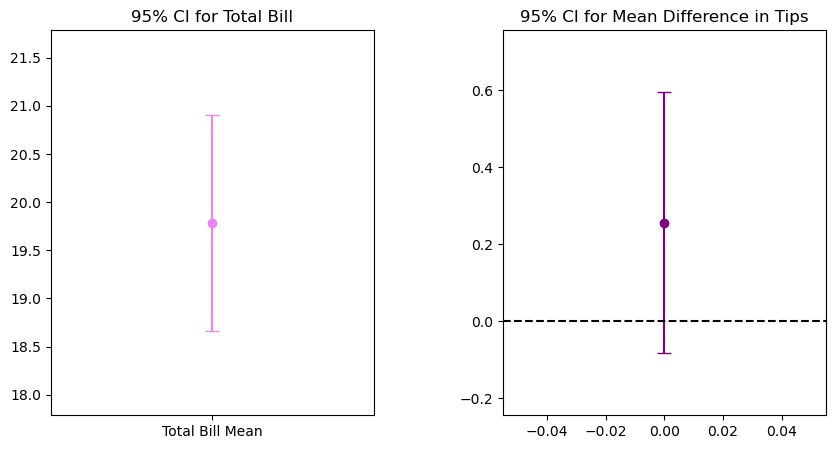

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.errorbar(x=[0], y=[mean_bill], yerr=[(ci_bill[1]-ci_bill[0])/2], fmt='o', capsize=5, color='violet')
plt.xticks([0], ['Total Bill Mean'])
plt.title('95% CI for Total Bill')
plt.ylim(mean_bill - 2, mean_bill + 2)
plt.subplot(1, 2, 2)
plt.errorbar(x=[0], y=[mean_diff], yerr=[(ci_diff[1]-ci_diff[0])/2], fmt='o', capsize=5, color='purple')
plt.axhline(0, color='black', linestyle='--') 
plt.title('95% CI for Mean Difference in Tips')
plt.ylim(mean_diff - 0.5, mean_diff + 0.5)
plt.subplots_adjust(wspace=0.4) 
plt.show()

**Total Bill Mean Confidence Interval:**

What it tells us: The 95% CI for the average total_bill is [18.66, 20.91]. This means we are 95% confident that the true population mean of the total bill falls within this range. It gives us a precise estimate of the "typical" spending of a customer in this restaurant.

Relation to Parameter: Since the interval is relatively narrow, it indicates that our sample mean (approx. 19.78) is a reliable estimate of the population parameter.

**Tip Difference (Male vs. Female) Confidence Interval:**

What it tells us: The 95% CI for the difference in tips between males and females is [-0.08, 0.59]. This interval represents the range of possible values for the difference in average tips given by the two groups.

Relation to Hypothesis Test: Crucially, this interval includes zero (0). In statistics, if a confidence interval for a difference includes zero, it suggests that there is no statistically significant difference between the groups.

Consistency: This result is perfectly consistent with our Mann-Whitney U test from Task 2, where the p-value was greater than 0.05. Both the hypothesis test and the confidence interval lead to the same conclusion: Gender does not have a significant effect on tip amounts.

## Task 4 — Power Analysis

In [9]:

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_sd = np.sqrt(((nx-1) * np.std(x, ddof=1)**2 + (ny-1) * np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pool_sd
male_tips = df[df['sex'] == 'Male']['tip']
female_tips = df[df['sex'] == 'Female']['tip']
effect_size = abs(cohen_d(male_tips, female_tips))
analysis = TTestIndPower()
alpha = 0.05
n_male = len(male_tips)
ratio = len(female_tips) / n_male
current_power = analysis.solve_power(effect_size=effect_size, nobs1=n_male, ratio=ratio, alpha=alpha)
required_n = analysis.solve_power(effect_size=effect_size, power=0.8, alpha=alpha, ratio=1)
print(f"Effect Size (Cohen's d): {effect_size:.4f}")
print(f"Current Statistical Power: {current_power:.4f}")
print(f"Minimum sample size per group for 80% power: {required_n:.0f}")

Effect Size (Cohen's d): 0.1855
Current Statistical Power: 0.2822
Minimum sample size per group for 80% power: 457


1. Effect Size (Cohen's d): > The calculated Cohen's d is 0.1855, which represents a small effect size. This indicates that the difference in tipping behavior between genders is minimal in this dataset.
2. Current Statistical Power: > Our post-hoc power analysis revealed a power of 0.2822 (approx. 28%). This is well below the conventional threshold of 0.80 (80%).
3. Interpretation and Reliability: > Because the power is so low, our non-significant result ($p > 0.05$) in Task 2 might be a Type II error. This means a real, albeit small, difference might exist in the population, but our current sample size of 244 is not large enough to detect it.
4. Required Sample Size: > To achieve 80% power for detecting this small effect, we would need at least 457 participants per group (over 900 in total).
5. Conclusion on Reliability: > Based on this analysis, while we did not find a significant difference, our conclusion is underpowered. The results should be interpreted with caution, as a larger dataset would be necessary to confirm the absence of a gender-based tipping difference with high confidence.

## Task 5 — Executive Summary

**Overview of Findings:**

This statistical analysis investigated the factors influencing customer spending and tipping behavior using the tips dataset. The primary focus was to determine if gender or smoking habits significantly impact the financial outcomes for the restaurant staff.

**Key Results:**

1. Distribution & Assumptions: Preliminary testing (Shapiro-Wilk) revealed that both total_bill and tip amounts are not normally distributed ($p < 0.0000$). Furthermore, Levene's test showed that the variance of total bills differs significantly between groups ($p = 0.0452$). Consequently, non-parametric methods were prioritized for analysis.
2. Hypothesis Testing: Using the Mann-Whitney U test, we found no statistically significant difference in tipping amounts between males and females ($p > 0.05$). Similarly, smoking habits did not show a significant association with the total bill amount.
3. Confidence & Precision: The 95% Confidence Interval for the difference in tips between genders was [-0.08, 0.59]. Since this interval includes zero, it reinforces the conclusion that any observed difference in our sample is likely due to chance rather than a systemic trend.

**Critical Evaluation (Power Analysis):**

While our initial tests suggest no significant differences, the Post-hoc Power Analysis indicates that our study is underpowered (Power ≈ 28%). The observed effect size ($d = 0.1855$) is small, meaning that to confirm these findings with 80% certainty, a much larger sample size (approx. 914 total participants) would be required.

**Final Conclusion:**

Based on the current dataset of 244 customers, there is no evidence to suggest that gender or smoking status influences tipping or spending. However, due to the small effect size and low statistical power, these results should be treated as preliminary. For a more definitive conclusion, further data collection is recommended.